# Motivating Example: 2-TX Duke Scene

**Scene:** Duke — two transmitters, Zone 1 (partial LOS) and Zone 2 (NLOS-heavy)  
**Frequency:** 3.5 GHz

Four baselines, each revealing a distinct weakness that motivates the proposed method:

| # | Baseline | Category | Weakness Exposed |
|---|----------|----------|------------------|
| 1 | `naive_edge_center` | Geometric heuristic | Empirical ~= ray-traced coverage |
| 2 | `empirical_pso` | Gradient-free + empirical | Channel model blind to blockage |
| 3 | `radiomap_gradient` | First-order + RadioMap | Near-zero gradients (binning approx.) |
| 4 | `dense_pathsolver_gradient` | First-order + PathSolver dense | Exact grads but O(zone²) per step |

In [1]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
SCENE_XML_PATH = "../scene/scenes/Duke/scene.xml"
CARRIER_HZ     = 3.5e9

# Iteration / sample budget (keep modest for the motivating example)
MOTIV_NUM_ITER       = 30
MOTIV_SAMPLES_PER_TX = int(1e7)

# ── TRANSMITTER 1 (same building as single-TX motivating example) ─────────────
TX1_NAME        = "gnb1"
TX1_BUILDING_ID = 12
TX1_HEIGHT_M    = 7.0

# ── TRANSMITTER 2 (NLOS-heavy zone on opposite side) ─────────────────────────
# NOTE: Confirm TX2_BUILDING_ID via the zone visualization cell below.
# Pick a building whose rooftop has sightlines partially blocked by surrounding
# buildings toward Zone 2 — makes the NLOS scenario visually clear.
TX2_NAME        = "gnb2"
TX2_BUILDING_ID = 9   # ← SET THIS after running the scene visualization
TX2_HEIGHT_M    = 7.0

# ── ZONE 1 (partial LOS — northwest quadrant) ─────────────────────────────────
ZONE1_CENTER   = [-190.0, 150.0]
ZONE1_WIDTH_M  = 200.0
ZONE1_HEIGHT_M = 200.0

# ── ZONE 2 (NLOS-heavy — southwest quadrant) ──────────────────────────────────
ZONE2_CENTER   = [-50.0, -50.0]
ZONE2_WIDTH_M  = 200.0
ZONE2_HEIGHT_M = 200.0

# ── RADIO MAP ─────────────────────────────────────────────────────────────────
MAP_CONFIG = {
    'center':        [0.0, 0.0, 0.0],
    'size':          [1400, 1400],
    'cell_size':     (1, 1),
    'ground_height': 0.0,
}

# ── EXPERIMENT ────────────────────────────────────────────────────────────────
NOISE_POWER = 1e-10
JITTER_SEED = 42
JITTER_MAG  = 0.0

In [2]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import mitsuba as mi

try:
    import sionna.rt
except ImportError:
    os.system("pip install sionna-rt")
    import sionna.rt

from sionna.rt import load_scene, AntennaArray
from sionna.rt.antenna_pattern import antenna_pattern_registry

from scene_parser import extract_building_info
from tx_placement import TxPlacement
from boresight_pathsolver import create_zone_mask
from angle_utils import compute_initial_angles_from_position, azimuth_elevation_to_yaw_pitch
from multi_tx_optimizer import TxConfig
from experiment_runner import (
    compare_all_results, plot_cdf, plot_metric_bars, plot_zone_overview,
)
from motivating_baselines import (
    naive_edge_center_baseline_multi_tx,
    empirical_pso_baseline_multi_tx,
    radiomap_gradient_baseline_multi_tx,
    dense_pathsolver_gradient_baseline_multi_tx,
)

scene = load_scene(SCENE_XML_PATH)
scene.frequency = CARRIER_HZ

single_el = np.array([[0.0, 0.0, 0.0]])
scene.tx_array = AntennaArray(
    antenna_pattern=antenna_pattern_registry.get("tr38901")(polarization="V"),
    normalized_positions=single_el.T,
)
scene.rx_array = AntennaArray(
    antenna_pattern=antenna_pattern_registry.get("iso")(polarization="V"),
    normalized_positions=single_el.T,
)
for rm in scene.radio_materials.values():
    rm.scattering_coefficient = 0.4

building_info = extract_building_info(SCENE_XML_PATH, verbose=False)
print(f"Scene loaded  |  {CARRIER_HZ/1e9:.1f} GHz  |  {len(building_info)} buildings")

2026-04-19 19:40:09 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Scene loaded  |  3.5 GHz  |  154 buildings


In [3]:
# ── ZONE MASKS ────────────────────────────────────────────────────────────────
zone_params1 = {'center': ZONE1_CENTER, 'width': ZONE1_WIDTH_M, 'height': ZONE1_HEIGHT_M}
zone_mask1, look_at1, zone_stats1 = create_zone_mask(
    map_config=MAP_CONFIG, zone_type='box', zone_params=zone_params1,
    target_height=1.5, scene_xml_path=SCENE_XML_PATH, exclude_buildings=True,
)

zone_params2 = {'center': ZONE2_CENTER, 'width': ZONE2_WIDTH_M, 'height': ZONE2_HEIGHT_M}
zone_mask2, look_at2, zone_stats2 = create_zone_mask(
    map_config=MAP_CONFIG, zone_type='box', zone_params=zone_params2,
    target_height=1.5, scene_xml_path=SCENE_XML_PATH, exclude_buildings=True,
)

print(f"Zone 1 (NW): {zone_stats1['num_cells']:6d} cells  centroid={[round(v,1) for v in zone_stats1['centroid_xy']]}")
print(f"Zone 2 (SW): {zone_stats2['num_cells']:6d} cells  centroid={[round(v,1) for v in zone_stats2['centroid_xy']]}")

Zone 1 (NW):  30406 cells  centroid=[-198.4, 137.1]
Zone 2 (SW):  25811 cells  centroid=[-56.4, -57.2]


In [4]:
# ── TX PLACEMENTS ─────────────────────────────────────────────────────────────
tx_placer1 = TxPlacement(scene, TX1_NAME, SCENE_XML_PATH, TX1_BUILDING_ID, offset=TX1_HEIGHT_M)
tx_placer1.set_rooftop_center()
tx1     = scene.get(TX1_NAME)
tx1_pos = tx1.position.numpy().flatten().tolist()
print(f"TX1 on building {TX1_BUILDING_ID} at ({tx1_pos[0]:.2f}, {tx1_pos[1]:.2f}, {tx1_pos[2]:.2f})")

assert TX2_BUILDING_ID is not None, "Set TX2_BUILDING_ID in the config cell first!"
tx_placer2 = TxPlacement(scene, TX2_NAME, SCENE_XML_PATH, TX2_BUILDING_ID, offset=TX2_HEIGHT_M)
tx_placer2.set_rooftop_center()
tx2     = scene.get(TX2_NAME)
tx2_pos = tx2.position.numpy().flatten().tolist()
print(f"TX2 on building {TX2_BUILDING_ID} at ({tx2_pos[0]:.2f}, {tx2_pos[1]:.2f}, {tx2_pos[2]:.2f})")

TX1 on building 12 at (-10.85, 329.46, 24.50)
TX2 on building 9 at (-272.42, -63.06, 24.50)


In [5]:
# ── INITIAL JITTER ────────────────────────────────────────────────────────────
rng = np.random.default_rng(JITTER_SEED)

def _jitter_tx(tx_obj, tx_pos, zone_stats, rng):
    base_az, base_el = compute_initial_angles_from_position(tx_pos, zone_stats["look_at_xyz"])
    az  = base_az + float(rng.uniform(-JITTER_MAG, JITTER_MAG))
    el  = base_el + float(rng.uniform(-JITTER_MAG, JITTER_MAG))
    yaw, pitch = azimuth_elevation_to_yaw_pitch(az, el)
    tx_obj.orientation = [float(yaw), float(pitch), 0.0]
    return az, el, yaw, pitch

az1, el1, yaw1, pitch1 = _jitter_tx(tx1, tx1_pos, zone_stats1, rng)
az2, el2, yaw2, pitch2 = _jitter_tx(tx2, tx2_pos, zone_stats2, rng)

# Store initial state for restoration between baselines
_init = {
    TX1_NAME: (tx1_pos[:], yaw1, pitch1),
    TX2_NAME: (tx2_pos[:], yaw2, pitch2),
}

def _restore_both_tx():
    """Reset both TXs to their jittered initial state before each baseline."""
    for name, (pos, yaw, pitch) in _init.items():
        tx = scene.get(name)
        tx.position    = mi.Point3f(float(pos[0]), float(pos[1]), float(pos[2]))
        tx.orientation = mi.Point3f(float(yaw), float(pitch), 0.0)

print(f"TX1  Az={az1:.6f}°  El={el1:.6f}°")
print(f"TX2  Az={az2:.6f}°  El={el2:.6f}°")

Tx Position: [-10.852537155151367, 329.458984375, 24.5]
look_at_position: [-190.0, 150.0, 1.5]
Tx Position: [-272.4181213378906, -63.0598030090332, 24.5]
look_at_position: [-50.0, -50.0, 1.5]
TX1  Az=225.049773°  El=-5.182752°
TX2  Az=3.360398°  El=-5.893826°


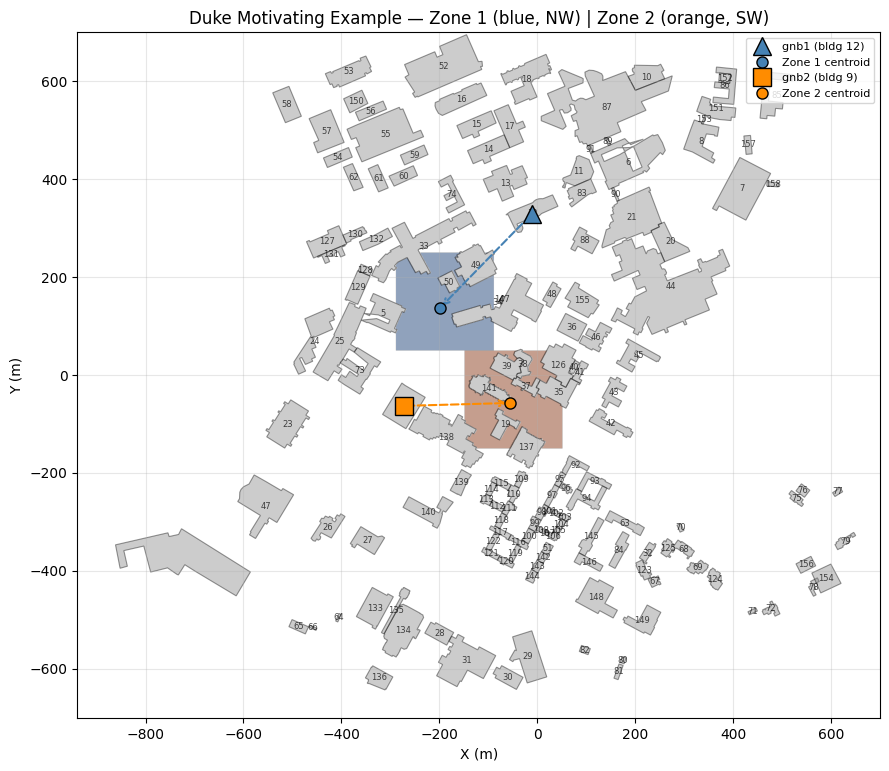

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Duke Motivating Example — Zone 1 (blue, NW) | Zone 2 (orange, SW)'}, xlabel='X (m)', ylabel='Y (m)'>)

In [6]:
# ── ZONE + TX VISUALIZATION ───────────────────────────────────────────────────
zone_entries = [
    dict(mask=zone_mask1, cmap='Blues', color='steelblue',
         tx_pos=tx1_pos, tx_name=TX1_NAME, building_id=TX1_BUILDING_ID,
         centroid_xy=zone_stats1['centroid_xy'], zone_label='Zone 1 centroid', marker='^'),
    dict(mask=zone_mask2, cmap='Oranges', color='darkorange',
         tx_pos=tx2_pos, tx_name=TX2_NAME, building_id=TX2_BUILDING_ID,
         centroid_xy=zone_stats2['centroid_xy'], zone_label='Zone 2 centroid', marker='s'),
]
plot_zone_overview(
    building_info, MAP_CONFIG, zone_entries,
    title='Duke Motivating Example — Zone 1 (blue, NW) | Zone 2 (orange, SW)',
    figsize=(9, 9),
)

In [7]:
# ── TX CONFIGS ────────────────────────────────────────────────────────────────
# Pin initial_azimuth_deg / initial_elevation_deg to the jittered values from
# cell-5 so every baseline starts from exactly the same orientation regardless
# of what the previous run left in the scene.
tx_configs_2 = [
    TxConfig(name=TX1_NAME, building_id=TX1_BUILDING_ID,
             zone_params=zone_params1, tx_height_offset=TX1_HEIGHT_M,
             num_sample_points=125,
             initial_azimuth_deg=az1, initial_elevation_deg=el1),
    TxConfig(name=TX2_NAME, building_id=TX2_BUILDING_ID,
             zone_params=zone_params2, tx_height_offset=TX2_HEIGHT_M,
             num_sample_points=125,
             initial_azimuth_deg=az2, initial_elevation_deg=el2),
]
motiv_results = {}

## Baseline 1 — Naive Edge-Center
Places each TX on the building edge facing its zone centroid and aims geometrically.  
Runs both a 3GPP UMa empirical evaluation and a Sionna ray-traced evaluation to expose the gap.

In [8]:
_restore_both_tx()

result_edge = naive_edge_center_baseline_multi_tx(
    scene=scene,
    tx_configs=tx_configs_2,
    map_config=MAP_CONFIG,
    scene_xml_path=SCENE_XML_PATH,
    noise_power=NOISE_POWER,
    frequency_hz=CARRIER_HZ,
    verbose=True,
)
motiv_results["naive_edge_center"] = result_edge

print(f"\nEmpirical loss : {result_edge['joint']['empirical_loss']:.4f}")
print(f"Ray-traced loss: {result_edge['joint']['raytraced_loss']:.4f}")
print(f"Gap (Δ)        : {result_edge['joint']['raytraced_loss'] - result_edge['joint']['empirical_loss']:+.4f}")


NAIVE EDGE-CENTER BASELINE  (2 TX)
Tx Position: [-39.67384338378906, 291.0231018066406, 24.5]
look_at_position: [-199.66880491567807, 136.97315268734607, 1.5]
  gnb1: Az=223.9°  El=-5.9°  pos=(-39.7, 291.0)
Tx Position: [-228.77723693847656, -45.58987045288086, 24.5]
look_at_position: [-56.3706799681872, -57.211022351012076, 1.5]
  gnb2: Az=356.1°  El=-7.6°  pos=(-228.8, -45.6)

  Ray-traced loss : -0.9275
  Empirical loss  : -0.9890  (1.3s)


Empirical loss : -0.9890
Ray-traced loss: -0.9275
Gap (Δ)        : +0.0616


## Baseline 2 — Empirical PSO (3GPP UMa)
PSO driven by the UMa channel model — no ray tracing, no geometric scene knowledge.  
Shows that the empirical model cannot distinguish LOS from NLOS blockage.

In [9]:
_restore_both_tx()

result_emp_pso = empirical_pso_baseline_multi_tx(
    scene=scene,
    tx_configs=tx_configs_2,
    map_config=MAP_CONFIG,
    scene_xml_path=SCENE_XML_PATH,
    noise_power=NOISE_POWER,
    frequency_hz=CARRIER_HZ,
    n_particles=20,
    num_iterations=30,
    seed=42,
    verbose=True,
)
motiv_results["empirical_pso"] = result_emp_pso


EMPIRICAL PSO BASELINE  (20 particles × 30 iters, 2 TX)
  Channel model: 3GPP TR 38.901 UMa (no ray tracing)
  Iter   1/30  global_best=-0.9576  (0.0s)
  Iter   2/30  global_best=-0.9640  (0.0s)
  Iter   3/30  global_best=-0.9640  (0.0s)
  Iter   4/30  global_best=-0.9732  (0.0s)
  Iter   5/30  global_best=-0.9807  (0.0s)
  Iter   6/30  global_best=-0.9808  (0.0s)
  Iter   7/30  global_best=-0.9815  (0.0s)
  Iter   8/30  global_best=-0.9826  (0.0s)
  Iter   9/30  global_best=-0.9830  (0.0s)
  Iter  10/30  global_best=-0.9842  (0.0s)
  Iter  11/30  global_best=-0.9852  (0.0s)
  Iter  12/30  global_best=-0.9857  (0.0s)
  Iter  13/30  global_best=-0.9863  (0.0s)
  Iter  14/30  global_best=-0.9869  (0.0s)
  Iter  15/30  global_best=-0.9872  (0.0s)
  Iter  16/30  global_best=-0.9875  (0.0s)
  Iter  17/30  global_best=-0.9877  (0.0s)
  Iter  18/30  global_best=-0.9877  (0.0s)
  [early stop] no improvement over last 5 iters at iter 18

  Best loss (empirical): -0.9877  (0.3s)
  gnb1: Az=225.

## Baseline 3 — RadioMap Gradient (Adam)
First-order optimization via `RadioMapSolver`.  Gradient norms are expected to be near-zero due to solid-angle ray-tube binning — signal at a cell only changes when a ray crosses a bin boundary, producing piecewise-constant gradients.

from multi_tx_optimizer import compare_multi_tx_performance

_restore_both_tx()

result_rm_grad = radiomap_gradient_baseline_multi_tx(
    scene=scene,
    tx_configs=tx_configs_2,
    map_config=MAP_CONFIG,
    scene_xml_path=SCENE_XML_PATH,
    noise_power=NOISE_POWER,
    frequency_hz=CARRIER_HZ,
    learning_rate=1.2,
    num_iterations=MOTIV_NUM_ITER,
    samples_per_tx=MOTIV_SAMPLES_PER_TX,
    n_empirical_pts=500,
    verbose=True,
)
motiv_results["radiomap_gradient"] = result_rm_grad

print(f"\nGrad norm  — mean: {float(np.mean(result_rm_grad['joint']['grad_norm_history'])):.2e}"
      f"  min: {float(np.min(result_rm_grad['joint']['grad_norm_history'])):.2e}"
      f"  max: {float(np.max(result_rm_grad['joint']['grad_norm_history'])):.2e}")

_restore_both_tx()   # reset scene to initial state first

fig, stats = compare_multi_tx_performance(
    scene       = scene,
    tx_configs  = tx_configs_2,
    multi_result= motiv_results["radiomap_gradient"],  # or any other result dict
    map_config  = MAP_CONFIG,
    zone_masks  = [zone_mask1, zone_mask2],            # list is fine now
    noise_power = NOISE_POWER,
    samples_per_tx = int(1e7),                         # fast for motivating figure
)


## Baseline 4 — Dense PathSolver Gradient (Adam)
First-order optimization via PathSolver over a full dense receiver grid.  Gradient magnitudes should be significantly larger than Baseline 3, but per-iteration time scales as O(zone²/spacing²).

_restore_both_tx()

result_dense = dense_pathsolver_gradient_baseline_multi_tx(
    scene=scene,
    tx_configs=tx_configs_2,
    map_config=MAP_CONFIG,
    scene_xml_path=SCENE_XML_PATH,
    learning_rate=3.5,
    noise_power=NOISE_POWER,
    num_iterations=MOTIV_NUM_ITER,
    verbose=True,
)
motiv_results["dense_pathsolver"] = result_dense

print(f"\nReceivers used : {result_dense['joint']['n_receivers']}")
print(f"Grad norm      — mean: {float(np.mean(result_dense['joint']['grad_norm_history'])):.2e}"
      f"  min: {float(np.min(result_dense['joint']['grad_norm_history'])):.2e}"
      f"  max: {float(np.max(result_dense['joint']['grad_norm_history'])):.2e}")
print(f"Mean iter time : {float(np.mean(result_dense['joint']['iter_time_history'])):.1f}s")

## Summary

# ── GRAD PATHOLOGY ANALYSIS (Baselines 3 vs 4) ────────────────────────────────
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.48, wspace=0.38)

_methods = [
    ("RadioMap (B3)",         result_rm_grad, "tab:red"),
    ("PathSolver dense (B4)", result_dense,   "tab:blue"),
]

# ── Row 0: normalized loss | mean grad norm ───────────────────────────────────
ax_loss  = fig.add_subplot(gs[0, :2])
ax_gnorm = fig.add_subplot(gs[0, 2:])

for label, res, color in _methods:
    hist = np.array(res['joint']['loss_history'], dtype=float)
    lo, hi = hist.min(), hist.max()
    norm_hist = (hist - lo) / (hi - lo) if hi > lo else np.zeros_like(hist)
    ax_loss.plot(norm_hist, label=label, color=color, linewidth=1.5)

    ax_gnorm.plot(res['joint']['grad_norm_history'], label=label, color=color, linewidth=1.5)

ax_loss.set_xlabel('Iteration')
ax_loss.set_ylabel('Normalized Loss [0, 1]')
ax_loss.set_title('Normalized Loss Curves')
ax_loss.legend(fontsize=8)
ax_loss.grid(True, alpha=0.3)

ax_gnorm.set_xlabel('Iteration')
ax_gnorm.set_ylabel('Mean |∇param|')
ax_gnorm.set_title('Mean Gradient Magnitude (log)')
ax_gnorm.set_yscale('log')
ax_gnorm.legend(fontsize=8)
ax_gnorm.grid(True, alpha=0.3)

# ── Row 1: per-param gradients (az, el) for each TX ──────────────────────────
_tx_names   = [TX1_NAME, TX2_NAME]
_param_keys = ["az", "el"]

for tx_i, tx_name in enumerate(_tx_names):
    for p_i, pname in enumerate(_param_keys):
        ax = fig.add_subplot(gs[1, tx_i * 2 + p_i])
        for label, res, color in _methods:
            pgh  = res['joint'].get('param_grad_histories', {})
            vals = pgh.get(tx_name, {}).get(pname)
            if vals:
                ax.plot(vals, label=label, color=color, linewidth=1.5)
        ax.set_xlabel('Iteration')
        ax.set_ylabel('|∇|')
        ax.set_title(f'{tx_name} — {pname} gradient')
        ax.set_yscale('log')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.suptitle('Duke Motivating Example — Gradient Pathology Analysis', y=1.01)
plt.show()

# ── GRADIENT COSINE SIMILARITY (Baselines 3 vs 4) ─────────────────────────────
# cos(∇_t, ∇_{t+1}) near +1 → consistent descent direction (good)
# cos(∇_t, ∇_{t+1}) near -1 → gradient direction-flipping (explains oscillation)

def _cosine_similarities(grad_vecs):
    sims = []
    for t in range(1, len(grad_vecs)):
        a = np.array(grad_vecs[t - 1], dtype=float)
        b = np.array(grad_vecs[t],     dtype=float)
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        sims.append(float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0)
    return sims

_methods = [
    ("RadioMap (B3)",         result_rm_grad, "tab:red"),
    ("PathSolver dense (B4)", result_dense,   "tab:blue"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax_cos  = axes[0]
ax_hist = axes[1]

for label, res, color in _methods:
    gvh  = res['joint'].get('grad_vector_history', [])
    sims = _cosine_similarities(gvh)
    xs   = list(range(1, len(sims) + 1))

    ax_cos.plot(xs, sims, label=label, color=color, linewidth=1.5)
    ax_hist.hist(sims, bins=20, alpha=0.5, label=label, color=color,
                 density=True, edgecolor='white', linewidth=0.4)

ax_cos.axhline(0,  color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax_cos.axhline(1,  color='grey',  linewidth=0.6, linestyle=':',  alpha=0.4)
ax_cos.axhline(-1, color='grey',  linewidth=0.6, linestyle=':',  alpha=0.4)
ax_cos.set_xlabel('Iteration')
ax_cos.set_ylabel('cos(∇_t, ∇_{t+1})')
ax_cos.set_title('Gradient Direction Cosine Similarity')
ax_cos.set_ylim(-1.1, 1.1)
ax_cos.legend(fontsize=8)
ax_cos.grid(True, alpha=0.3)

ax_hist.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax_hist.set_xlabel('cos(∇_t, ∇_{t+1})')
ax_hist.set_ylabel('Density')
ax_hist.set_title('Distribution of Cosine Similarities')
ax_hist.legend(fontsize=8)
ax_hist.grid(True, alpha=0.3)

# Print summary stats
for label, res, _ in _methods:
    gvh  = res['joint'].get('grad_vector_history', [])
    sims = _cosine_similarities(gvh)
    if sims:
        print(f"{label:30s}  mean cos={np.mean(sims):+.3f}  "
              f"median={np.median(sims):+.3f}  "
              f"frac<0={np.mean(np.array(sims) < 0):.2%}")

plt.suptitle('Duke Motivating Example — Gradient Direction Consistency', y=1.02)
plt.tight_layout()
plt.show()

# ── RAY-TRACED SINR CDFs (Baselines 2, 3, 4) ──────────────────────────────────
# Runs RadioMapSolver on each method's final configuration to get per-cell SINR
# arrays for CDF comparison across the three gradient/zeroth-order baselines.

_sinr_entries = [
    ("Empirical PSO (B2)",    result_emp_pso, "tab:purple"),
    ("RadioMap Grad (B3)",    result_rm_grad,  "tab:red"),
    ("Dense PathSolver (B4)", result_dense,    "tab:blue"),
]

_sinr_stats = {}
for _label, _result, _color in _sinr_entries:
    _, _stats = compare_multi_tx_performance(
        scene=scene,
        tx_configs=tx_configs_2,
        multi_result=_result,
        map_config=MAP_CONFIG,
        zone_masks=[zone_mask1, zone_mask2],
        noise_power=NOISE_POWER,
        samples_per_tx=int(1e7),
        fig=False,
    )
    _sinr_stats[_label] = (_stats, _color)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
_zone_specs = [
    (TX1_NAME, "Zone 1 (NW)"),
    (TX2_NAME, "Zone 2 (SW)"),
    (None,     "All Zones Combined"),
]

for ax_i, (tx_name, zone_label) in enumerate(_zone_specs):
    ax = axes[ax_i]
    for _label, (_stats, _color) in _sinr_stats.items():
        if tx_name is not None:
            sinr_vals = np.array(_stats[tx_name]["optimized"]["sir_values_db"])
        else:
            sinr_vals = np.concatenate([
                np.array(_stats[TX1_NAME]["optimized"]["sir_values_db"]),
                np.array(_stats[TX2_NAME]["optimized"]["sir_values_db"]),
            ])
        sorted_v = np.sort(sinr_vals)
        cdf = np.arange(1, len(sorted_v) + 1) / len(sorted_v)
        ax.plot(sorted_v, cdf, label=_label, color=_color, linewidth=1.5)
    ax.set_xlabel("SINR (dB)")
    ax.set_ylabel("CDF")
    ax.set_title(f"Ray-traced SINR — {zone_label}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle("Duke Motivating Example — Ray-traced SINR CDFs (Optimized Configs)", y=1.02)
plt.tight_layout()
plt.show()

## Scaling Experiment — Sample Count vs. Convergence Speed

Compares six methods with position included in the optimization parameter set alongside azimuth/elevation.
Dense PathSolver variants span three grid resolutions (10 m → 2.5 m); triangulated SGD uses 75 stochastic samples per zone per iteration.
The goal is to show that keeping the sample count low (SGD regime) matches or exceeds the convergence quality of the dense grid at a fraction of the per-iteration cost.

In [10]:
# ── SCALING EXPERIMENT — SECTOR MAP CONFIGS + ZONE MASKS ──────────────────────
# Each dense solver run uses a MAP_CONFIG whose cell_size matches grid_spacing,
# so stride=1: every zone-mask cell becomes exactly one receiver.

_sector_map_configs = {
    "50m":  {**MAP_CONFIG, 'cell_size': (50.0, 50.0)},
    "25m":  {**MAP_CONFIG, 'cell_size': (25.0, 25.0)},
    "20m":  {**MAP_CONFIG, 'cell_size': (20.0, 20.0)},
    "10m":  {**MAP_CONFIG, 'cell_size': (10.0, 10.0)},
    "5m":   MAP_CONFIG,                                    # already computed at startup
    "2.5m": {**MAP_CONFIG, 'cell_size': (2.5,  2.5)},
}

_zone_masks_by_sector = {"5m": (zone_mask1, zone_mask2)}

for _sz in ["50m", "25m", "20m", "10m", "2.5m"]:
    _mc = _sector_map_configs[_sz]
    _zm1, _, _zs1 = create_zone_mask(
        map_config=_mc, zone_type='box', zone_params=zone_params1,
        target_height=1.5, scene_xml_path=SCENE_XML_PATH, exclude_buildings=True,
    )
    _zm2, _, _zs2 = create_zone_mask(
        map_config=_mc, zone_type='box', zone_params=zone_params2,
        target_height=1.5, scene_xml_path=SCENE_XML_PATH, exclude_buildings=True,
    )
    _zone_masks_by_sector[_sz] = (_zm1, _zm2)
    print(f"  {_sz:>5}  Zone1={_zs1['num_cells']:7d} cells  Zone2={_zs2['num_cells']:7d} cells")

# Pin initial angles so scaling runs start from the same point as all other baselines.
_tx_configs_scale = [
    TxConfig(name=TX1_NAME, building_id=TX1_BUILDING_ID,
             zone_params=zone_params1, tx_height_offset=TX1_HEIGHT_M,
             num_sample_points=150,
             initial_azimuth_deg=az1, initial_elevation_deg=el1),
    TxConfig(name=TX2_NAME, building_id=TX2_BUILDING_ID,
             zone_params=zone_params2, tx_height_offset=TX2_HEIGHT_M,
             num_sample_points=150,
             initial_azimuth_deg=az2, initial_elevation_deg=el2),
]
print("\nSector configs and zone masks ready.")


    50m  Zone1=     13 cells  Zone2=      7 cells
    25m  Zone1=     46 cells  Zone2=     40 cells
    20m  Zone1=     89 cells  Zone2=     81 cells
    10m  Zone1=    306 cells  Zone2=    257 cells
   2.5m  Zone1=   4855 cells  Zone2=   4126 cells

Sector configs and zone masks ready.


In [11]:
# ── SCALING EXPERIMENT — RUN ALL METHODS ──────────────────────────────────────
from multi_tx_optimizer import optimize_multi_tx

def _print_position_check(result, tx_configs):
    for cfg in tx_configs:
        r  = result[cfg.name]
        x0, y0 = r["initial_position"][0], r["initial_position"][1]
        xf, yf = r["final_position"][0],   r["final_position"][1]
        dx, dy = xf - x0, yf - y0
        print(f"    {cfg.name}  init=({x0:.1f}, {y0:.1f})  "
              f"final=({xf:.1f}, {yf:.1f})  Δ=({dx:+.1f}, {dy:+.1f})")

scaling_results = {}

# Dense PathSolver — 4 grid resolutions including the new super-sparse 20 m run
# tx_configs_2 has pinned initial_azimuth_deg/initial_elevation_deg (az1/el1, az2/el2)
for _sz, _spacing in [("50m", 25.0), ("25m", 25.0),("20m", 20.0)]:
    print(f"\n{'─'*56}")
    print(f"  Dense PathSolver  grid={_sz}")
    print(f"{'─'*56}")
    _restore_both_tx()
    _result = dense_pathsolver_gradient_baseline_multi_tx(
        scene=scene,
        tx_configs=tx_configs_2,
        map_config=_sector_map_configs[_sz],
        scene_xml_path=SCENE_XML_PATH,
        noise_power=NOISE_POWER,
        learning_rate=3.5,
        num_iterations=MOTIV_NUM_ITER,
        grid_spacing=_spacing,
        verbose=True,
    )
    scaling_results[f"dense_{_sz}"] = _result
    _print_position_check(_result, tx_configs_2)

# Triangulated SGD — n = 64, 128, 256 samples per zone
# Pin the same initial angles as all other baselines.
for _n_pts in [10, 20, 30, 40]:
    print(f"\n{'─'*56}")
    print(f"  Triangulated SGD  ({_n_pts} pts / zone)")
    print(f"{'─'*56}")
    _tx_cfgs = [
        TxConfig(name=TX1_NAME, building_id=TX1_BUILDING_ID,
                 zone_params=zone_params1, tx_height_offset=TX1_HEIGHT_M,
                 num_sample_points=_n_pts,
                 initial_azimuth_deg=az1, initial_elevation_deg=el1),
        TxConfig(name=TX2_NAME, building_id=TX2_BUILDING_ID,
                 zone_params=zone_params2, tx_height_offset=TX2_HEIGHT_M,
                 num_sample_points=_n_pts,
                 initial_azimuth_deg=az2, initial_elevation_deg=el2),
    ]
    _restore_both_tx()
    _result = optimize_multi_tx(
        scene=scene,
        tx_configs=_tx_cfgs,
        map_config=MAP_CONFIG,
        scene_xml_path=SCENE_XML_PATH,
        noise_power=NOISE_POWER,
        learning_rate=3.5,
        num_iterations=MOTIV_NUM_ITER,
        sampler="triangulated",
        sampling_strata="full",
        sir_threshold_db=15,
        verbose=True,
    )
    scaling_results[f"triangulated_{_n_pts}"] = _result
    _print_position_check(_result, _tx_cfgs)

print("\nAll scaling runs complete.")
print(f"\n{'Method':<32}  {'Iters':>6}  {'s/iter':>8}  {'Receivers':>10}  {'Peak MB':>9}")
print("─" * 74)
for _key in ["dense_20m", "dense_10m", "dense_5m", "dense_2.5m",
             "triangulated_64", "triangulated_128", "triangulated_70"]:
    _r = scaling_results.get(_key)
    if _r is None:
        continue
    _j  = _r["joint"]
    _n  = len(_j["loss_history"])
    _t  = float(np.mean(_j.get("iter_time_history", [float("nan")])))
    _rx = _j.get("n_receivers", "—")
    _mb = _j.get("peak_memory_mb", float("nan"))
    print(f"  {_key:<30}  {_n:>6}  {_t:>8.2f}  {str(_rx):>10}  {_mb:>9.1f}")



────────────────────────────────────────────────────────
  Dense PathSolver  grid=50m
────────────────────────────────────────────────────────

DENSE PATHSOLVER BASELINE  (2 TX, 30 iters, lr=3.5, grid=25m)


  Zone gnb1: 13 receivers (25 m grid)
  Zone gnb2: 7 receivers (25 m grid)
  Total receivers: 20
  Iter   1/30  loss=-0.0497  |∇|=4.33e-04  (0.5s)
  Iter   2/30  loss=-0.1291  |∇|=3.65e-04  (0.5s)
  Iter   3/30  loss=-0.1704  |∇|=2.66e-04  (0.5s)
  Iter   4/30  loss=-0.1733  |∇|=2.73e-04  (0.5s)
  Iter   5/30  loss=-0.1826  |∇|=2.48e-04  (0.5s)
  Iter   6/30  loss=-0.1847  |∇|=2.53e-04  (0.5s)
  Iter   7/30  loss=-0.2291  |∇|=4.36e-04  (0.5s)
  Iter   8/30  loss=-0.2338  |∇|=4.02e-04  (0.5s)
  Iter   9/30  loss=-0.2392  |∇|=3.21e-04  (0.5s)
  Iter  10/30  loss=-0.1904  |∇|=1.15e-04  (0.5s)
  Iter  11/30  loss=-0.1918  |∇|=1.51e-04  (0.5s)
  Iter  12/30  loss=-0.1945  |∇|=1.88e-04  (0.5s)
  Iter  13/30  loss=-0.2476  |∇|=2.20e-04  (0.5s)
  Iter  14/30  loss=-0.2539  |∇|=2.10e-04  (0.5s)
  Iter  15/30  loss=-0.2466  |∇|=2.61e-04  (0.5s)
  Iter  16/30  loss=-0.2488  |∇|=2.37e-04  (0.5s)
  Iter  17/30  loss=-0.2493  |∇|=2.24e-04  (0.5s)
  Iter  18/30  loss=-0.2532  |∇|=1.99e-04  (0.5s)
  I

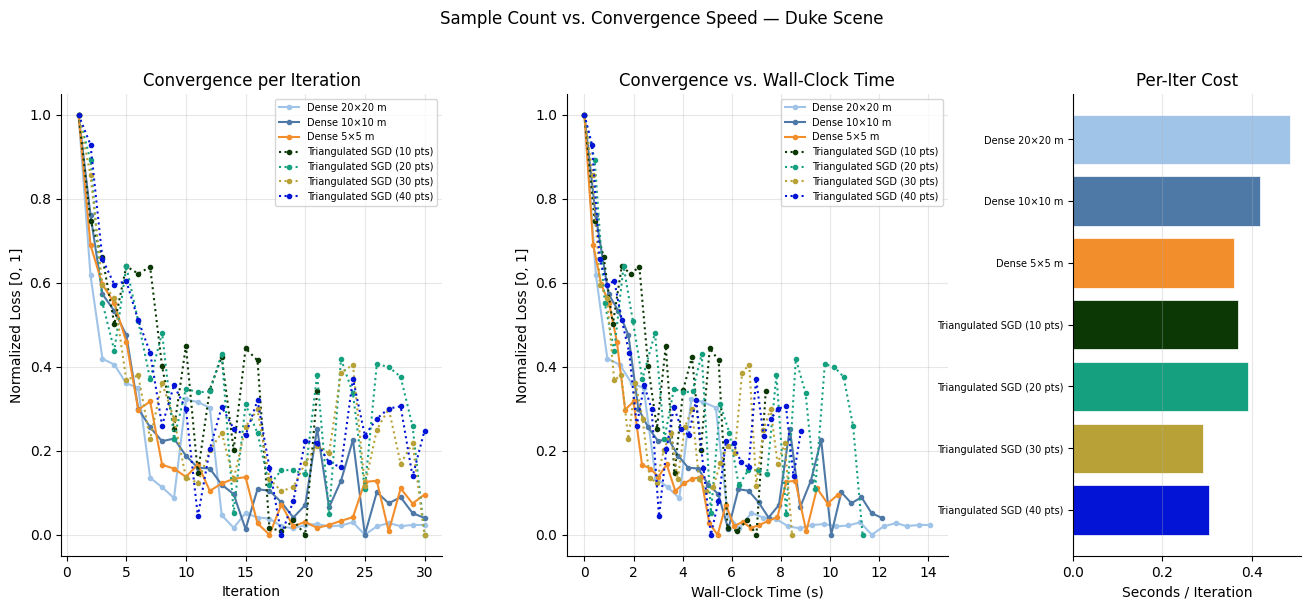


Method                             Receivers   s / iter   iters / min
──────────────────────────────────────────────────────────────────────
  Dense 20×20 m                           20       0.49         123.4
  Dense 10×10 m                           88       0.42         143.5
  Dense 5×5 m                            119       0.36         167.0
  Triangulated SGD (10 pts)               20       0.37         162.5
  Triangulated SGD (20 pts)               40       0.39         153.6
  Triangulated SGD (30 pts)               60       0.29         205.7
  Triangulated SGD (40 pts)               80       0.30         197.1


In [12]:
# ── SCALING SUMMARY PLOT ──────────────────────────────────────────────────────
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38, width_ratios=[2, 2, 1.2])

ax_iter = fig.add_subplot(gs[0])
ax_time = fig.add_subplot(gs[1])
ax_cost = fig.add_subplot(gs[2])

_colors = {
    "dense_50m":        "#a0c4e8",
    "dense_25m":        "#4e79a7",
    "dense_20m":         "#f28e2b",
    "dense_2.5m":       "#76b7b2",
    "triangulated_64":  "#742158",
    "triangulated_128": "#7dc475",
    "triangulated_10": "#0C3806",
    "triangulated_20": "#15A080",
    "triangulated_30": "#B8A238",
    "triangulated_40": "#0314D6"
}
_labels = {
    "dense_50m":        "Dense 20×20 m",
    "dense_25m":        "Dense 10×10 m",
    "dense_20m":         "Dense 5×5 m",
    "dense_2.5m":       "Dense 2.5×2.5 m",
    "triangulated_10":  "Triangulated SGD (10 pts)",
    "triangulated_20": "Triangulated SGD (20 pts)",
    "triangulated_30": "Triangulated SGD (30 pts)",
    "triangulated_40": "Triangulated SGD (40 pts)"
}
_linestyles = {
    "dense_50m":        "-",
    "dense_25m":        "-",
    "dense_20m":         "-",
    "dense_2.5m":       "-",
    "triangulated_10":  ":",
    "triangulated_20": ":",
    "triangulated_30": ":",
    "triangulated_40": ":"
}

_cost_rows = []

for key in ["dense_50m", "dense_25m", "dense_20m", "dense_2.5m",
            "triangulated_10", "triangulated_20", "triangulated_30", "triangulated_40"]:
    res = scaling_results.get(key)
    if res is None:
        continue
    joint  = res["joint"]
    loss   = np.array(joint["loss_history"], dtype=float)
    times  = np.array(joint.get("iter_time_history", []), dtype=float)

    lo, hi    = loss.min(), loss.max()
    norm_loss = (loss - lo) / (hi - lo) if hi > lo else np.zeros_like(loss)
    iters     = np.arange(1, len(loss) + 1)
    cum_time  = np.concatenate([[0.0], np.cumsum(times)])[:len(loss)]

    color = _colors[key]
    label = _labels[key]
    ls    = _linestyles[key]

    ax_iter.plot(iters, norm_loss, label=label, color=color,
                 linewidth=1.5, linestyle=ls, marker="o", markersize=3)
    ax_time.plot(cum_time, norm_loss, label=label, color=color,
                 linewidth=1.5, linestyle=ls, marker="o", markersize=3)

    n_rx   = joint.get("n_receivers", "—")
    mean_t = float(np.mean(times)) if len(times) > 0 else float("nan")
    _cost_rows.append((label, n_rx, mean_t, color))

ax_iter.set_xlabel("Iteration")
ax_iter.set_ylabel("Normalized Loss [0, 1]")
ax_iter.set_title("Convergence per Iteration")
ax_iter.legend(fontsize=7, loc="upper right")
ax_iter.grid(True, alpha=0.3)
ax_iter.spines[["top", "right"]].set_visible(False)

ax_time.set_xlabel("Wall-Clock Time (s)")
ax_time.set_ylabel("Normalized Loss [0, 1]")
ax_time.set_title("Convergence vs. Wall-Clock Time")
ax_time.legend(fontsize=7, loc="upper right")
ax_time.grid(True, alpha=0.3)
ax_time.spines[["top", "right"]].set_visible(False)

_bar_labels = [r[0] for r in _cost_rows]
_bar_times  = [r[2] for r in _cost_rows]
_bar_colors = [r[3] for r in _cost_rows]
_y = np.arange(len(_bar_labels))
ax_cost.barh(_y, _bar_times, color=_bar_colors, edgecolor="white", linewidth=0.5)
ax_cost.set_yticks(_y)
ax_cost.set_yticklabels(_bar_labels, fontsize=7)
ax_cost.set_xlabel("Seconds / Iteration")
ax_cost.set_title("Per-Iter Cost")
ax_cost.invert_yaxis()
ax_cost.grid(True, axis="x", alpha=0.3)
ax_cost.spines[["top", "right"]].set_visible(False)

plt.suptitle("Sample Count vs. Convergence Speed — Duke Scene", y=1.02)
plt.tight_layout()
plt.savefig("convergence_scaling_duke.pdf", bbox_inches="tight")
plt.show()

print(f"\n{'Method':<32}  {'Receivers':>10}  {'s / iter':>9}  {'iters / min':>12}")
print("─" * 70)
for label, n_rx, mean_t, _ in _cost_rows:
    ipm = 60.0 / mean_t if mean_t > 0 else float("nan")
    print(f"  {label:<30}  {str(n_rx):>10}  {mean_t:>9.2f}  {ipm:>12.1f}")



BEFORE / AFTER COMPARISON
  gnb1:
    Initial:   Az=225.0°, El=-5.2°, pos=(-10.9, 329.5)
    Optimised: Az=190.6°, El=-10.6°, pos=(-47.0, 301.3)
  gnb2:
    Initial:   Az=3.4°, El=-5.9°, pos=(-272.4, -63.1)
    Optimised: Az=1.1°, El=-7.6°, pos=(-228.8, -45.6)

Computing RadioMap for initial configuration...
Computing RadioMap for optimized configuration...

RESULTS
  gnb1  (30406 non-building zone cells):
    Coverage:      18.8%  →   28.6%  (+9.8 pp)
    RSRP mean:    -132.1 dBm  →   -124.2 dBm  (+7.9 dB)
    RSRP median:  -150.0 dBm  →   -150.0 dBm  (+0.0 dB)
    RSRP p10:     -150.0 dBm  →   -150.0 dBm  (+0.0 dB)
    RSRP p90:      -51.9 dBm  →    -51.5 dBm
    SIR mean:       +8.0 dB   →     +3.6 dB   (-4.4 dB)  [covered cells]
    SIR median:    +11.3 dB   →     +7.6 dB   (-3.7 dB)  [covered cells]
    SIR p10:       -20.0 dB   →    -26.2 dB   (-6.2 dB)  [covered cells]
    SIR p90:       +29.3 dB   →    +25.3 dB   [covered cells]
  gnb2  (25811 non-building zone cells):
    Cov

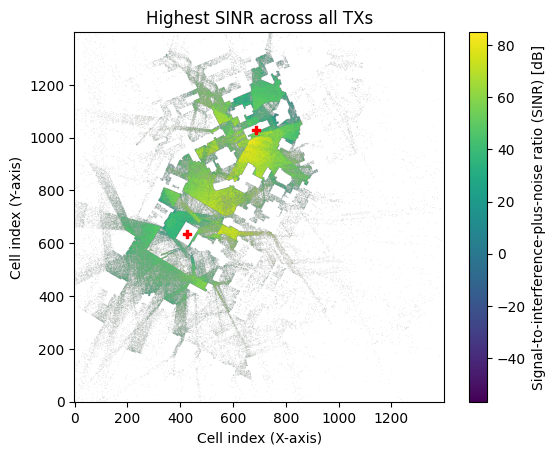

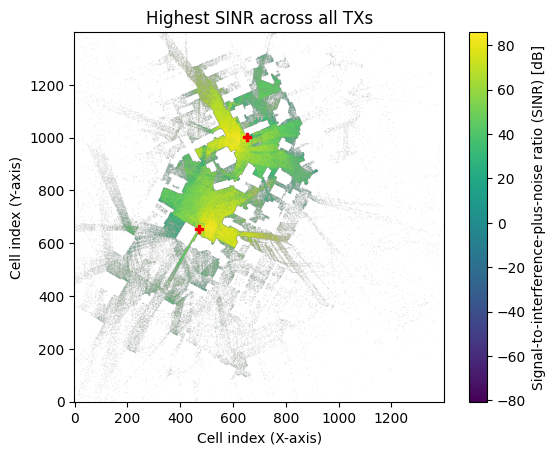

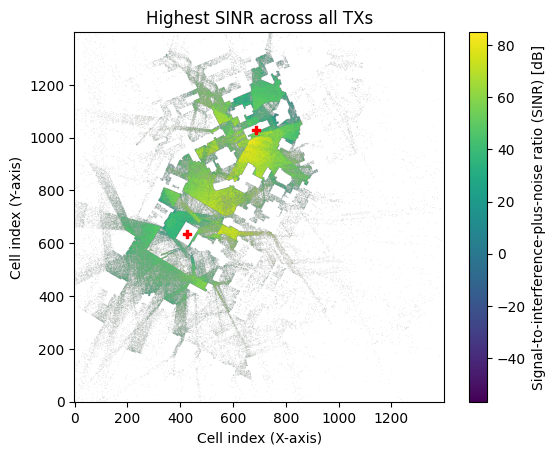

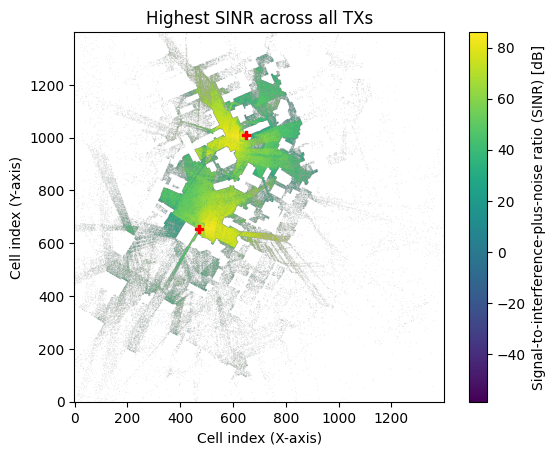

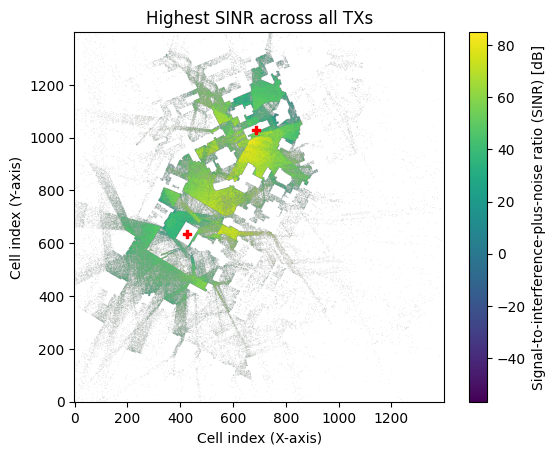

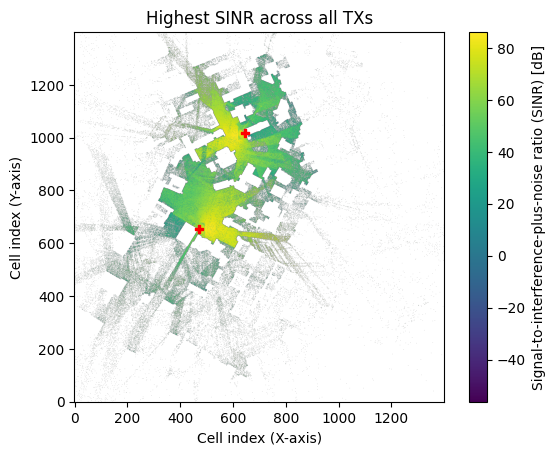

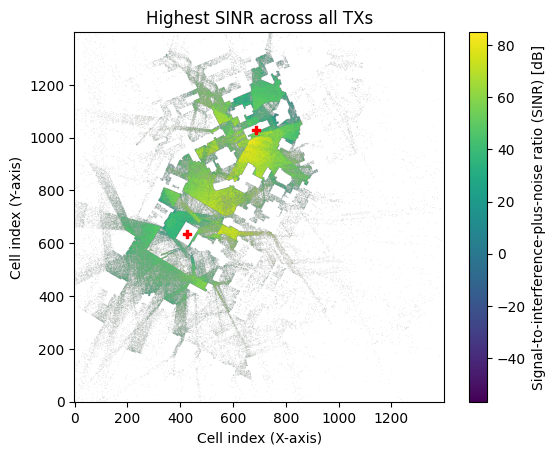

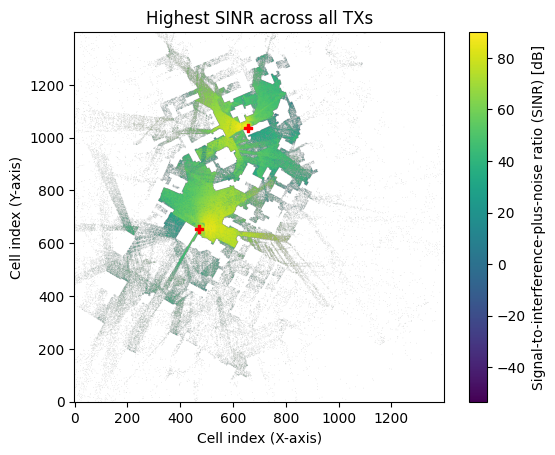

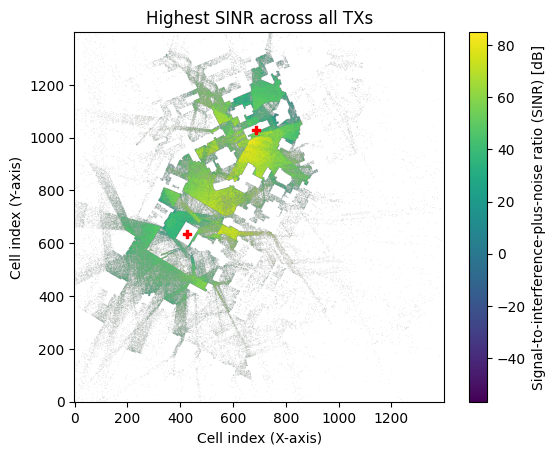

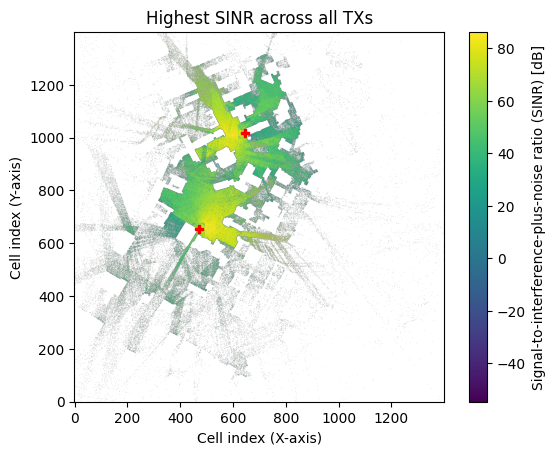

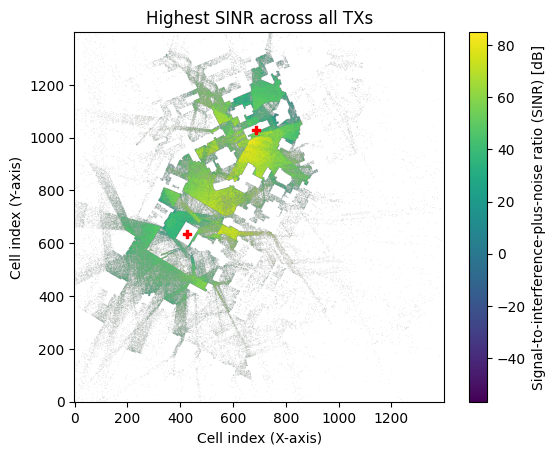

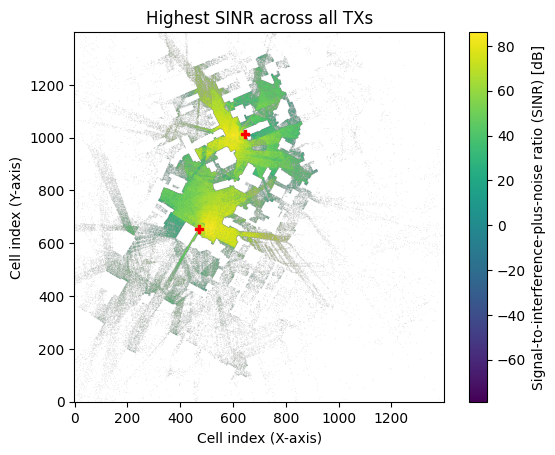

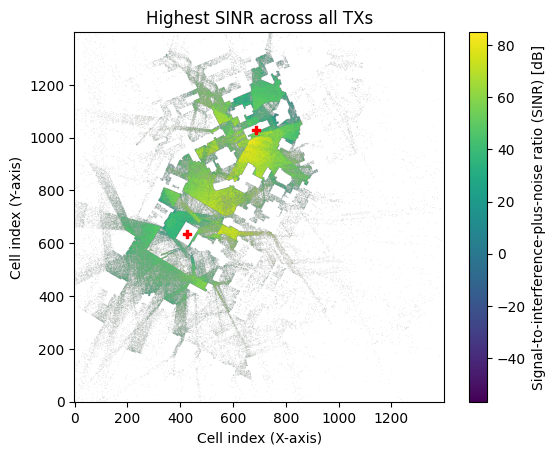

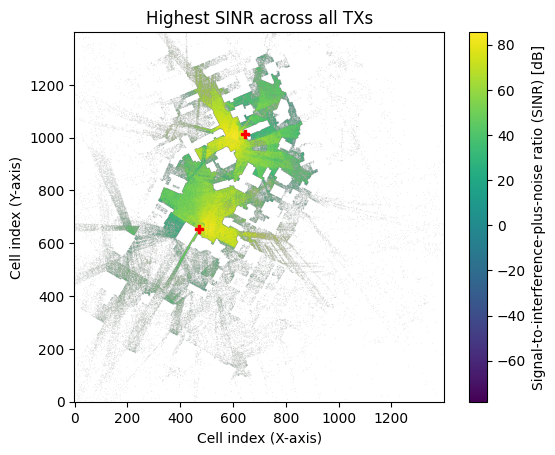

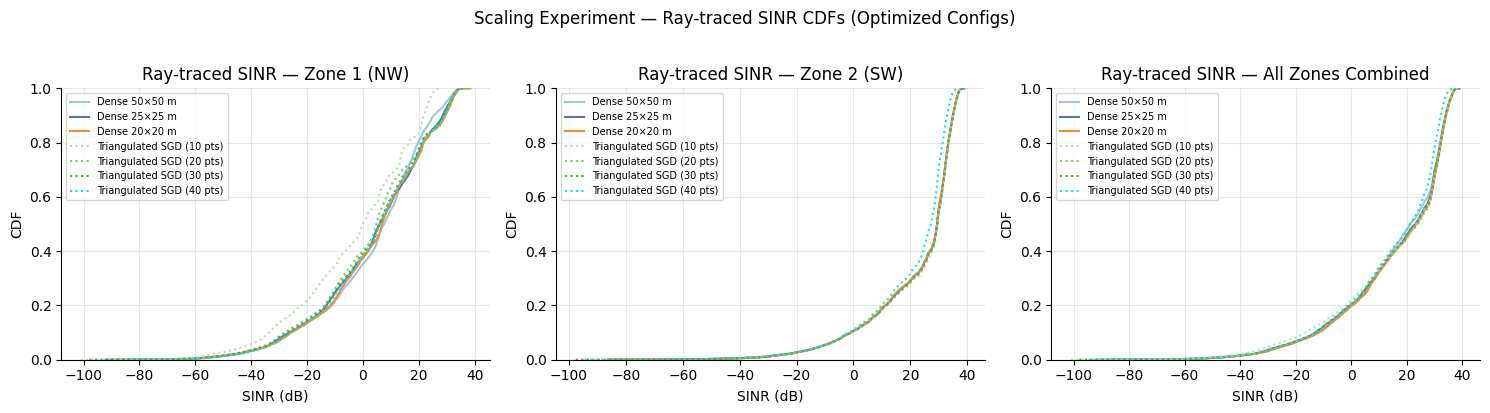

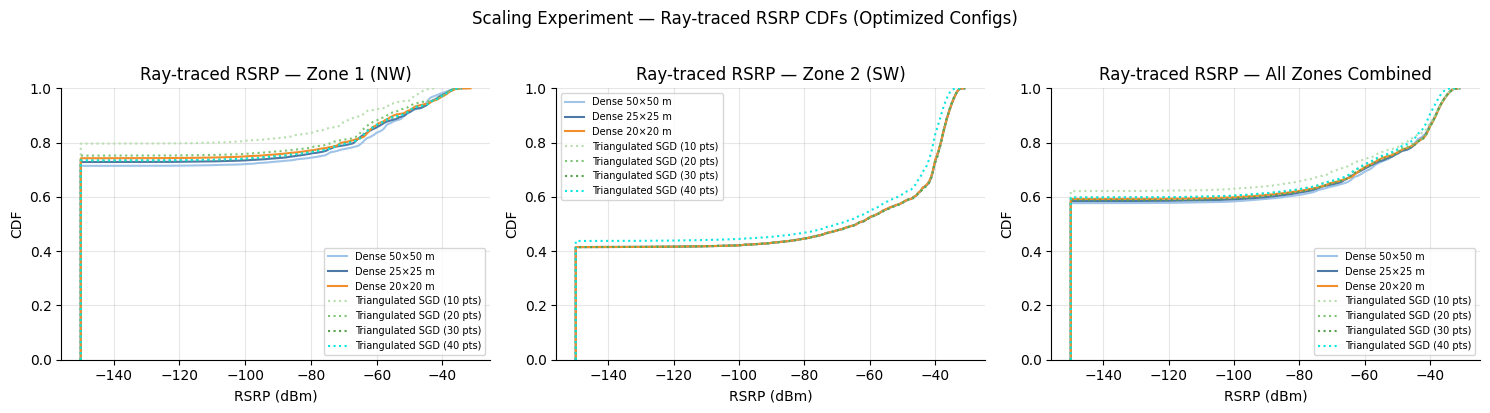

In [13]:
from multi_tx_optimizer import compare_multi_tx_performance

# ── SCALING EXPERIMENT — RAY-TRACED SINR CDFs ─────────────────────────────────
_scale_sinr_entries = [
    ("Dense 50×50 m",              "dense_50m",        tx_configs_2, "#a0c4e8"),
    ("Dense 25×25 m",              "dense_25m",        tx_configs_2, "#4e79a7"),
    ("Dense 20×20 m",                "dense_20m",         tx_configs_2, "#f28e2b"),
    ("Dense 2.5×2.5 m",            "dense_2.5m",       tx_configs_2, "#76b7b2"),
    ("Triangulated SGD (10 pts)",  "triangulated_10",  None,         "#b8deb0"),
    ("Triangulated SGD (20 pts)", "triangulated_20", None,         "#7dc475"),
    ("Triangulated SGD (30 pts)", "triangulated_30", None,         "#59a14f"),
    ("Triangulated SGD (40 pts)", "triangulated_40", None,         "#0be6e2")
]

_tri_cfgs = {
    n: [TxConfig(name=TX1_NAME, building_id=TX1_BUILDING_ID,
                 zone_params=zone_params1, tx_height_offset=TX1_HEIGHT_M,
                 num_sample_points=n),
        TxConfig(name=TX2_NAME, building_id=TX2_BUILDING_ID,
                 zone_params=zone_params2, tx_height_offset=TX2_HEIGHT_M,
                 num_sample_points=n)]
    for n in [10, 20, 30, 40]
}

_scale_sinr_stats = {}
for _label, _key, _cfgs_arg, _color in _scale_sinr_entries:
    _r = scaling_results.get(_key)
    if _r is None:
        continue
    _n_pts = int(_key.split("_")[-1]) if "triangulated" in _key else None
    _cfgs  = _cfgs_arg if _cfgs_arg is not None else _tri_cfgs[_n_pts]
    _, _stats = compare_multi_tx_performance(
        scene=scene,
        tx_configs=_cfgs,
        multi_result=_r,
        map_config=MAP_CONFIG,
        zone_masks=[zone_mask1, zone_mask2],
        noise_power=NOISE_POWER,
        samples_per_tx=int(1e7),
        fig=False,
    )
    _scale_sinr_stats[_label] = (_stats, _color)

_zone_specs = [
    (TX1_NAME, "Zone 1 (NW)"),
    (TX2_NAME, "Zone 2 (SW)"),
    (None,     "All Zones Combined"),
]

# ── SINR CDFs ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax_i, (tx_name, zone_label) in enumerate(_zone_specs):
    ax = axes[ax_i]
    for _label, (_stats, _color) in _scale_sinr_stats.items():
        _ls = ":" if "Triangulated" in _label else "-"
        if tx_name is not None:
            sinr_vals = np.array(_stats[tx_name]["optimized"]["sir_values_db"])
        else:
            sinr_vals = np.concatenate([
                np.array(_stats[TX1_NAME]["optimized"]["sir_values_db"]),
                np.array(_stats[TX2_NAME]["optimized"]["sir_values_db"]),
            ])
        sorted_v = np.sort(sinr_vals)
        cdf = np.arange(1, len(sorted_v) + 1) / len(sorted_v)
        ax.plot(sorted_v, cdf, label=_label, color=_color,
                linewidth=1.5, linestyle=_ls)
    ax.set_xlabel("SINR (dB)")
    ax.set_ylabel("CDF")
    ax.set_title(f"Ray-traced SINR — {zone_label}")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Scaling Experiment — Ray-traced SINR CDFs (Optimized Configs)", y=1.02)
plt.tight_layout()
plt.savefig("sinr_cdf_scaling_duke.pdf", bbox_inches="tight")
plt.show()

# ── RSRP CDFs ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax_i, (tx_name, zone_label) in enumerate(_zone_specs):
    ax = axes[ax_i]
    for _label, (_stats, _color) in _scale_sinr_stats.items():
        _ls = ":" if "Triangulated" in _label else "-"
        if tx_name is not None:
            rsrp_vals = np.array(_stats[tx_name]["optimized"]["rsrp_values_dbm"])
        else:
            rsrp_vals = np.concatenate([
                np.array(_stats[TX1_NAME]["optimized"]["rsrp_values_dbm"]),
                np.array(_stats[TX2_NAME]["optimized"]["rsrp_values_dbm"]),
            ])
        sorted_v = np.sort(rsrp_vals)
        cdf = np.arange(1, len(sorted_v) + 1) / len(sorted_v)
        ax.plot(sorted_v, cdf, label=_label, color=_color,
                linewidth=1.5, linestyle=_ls)
    ax.set_xlabel("RSRP (dBm)")
    ax.set_ylabel("CDF")
    ax.set_title(f"Ray-traced RSRP — {zone_label}")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Scaling Experiment — Ray-traced RSRP CDFs (Optimized Configs)", y=1.02)
plt.tight_layout()
plt.savefig("rsrp_cdf_scaling_duke.pdf", bbox_inches="tight")
plt.show()


## Zone Boundary KPI — Dense vs Triangulated Sampler

For each optimized configuration, the **dominant TX** per covered cell is the TX delivering the strongest signal.
A **boundary cell** is where that label changes across 8-connected neighbours — the spatial handover frontier where interference is highest.

The KPI characterises the SINR in a ±12 m neighbourhood around each boundary cell, capturing the quality of service experienced by UEs nearest the coverage edge.
Two representative methods are compared directly (Dense 2.5 m and Triangulated 256 pts), followed by a cross-method summary.


════════════════════════════════════════════════════════════
  Dense 25×25 m
════════════════════════════════════════════════════════════
  Boundary cells  :  161,540  →  134,884
  Boundary frac   :  0.691  →  0.608
  SINR nbhd mean  :  +2.3 dB  →  +1.3 dB  (-1.0 dB)
  SINR nbhd P10   :  -3.2 dB  →  -4.4 dB  (-1.2 dB)


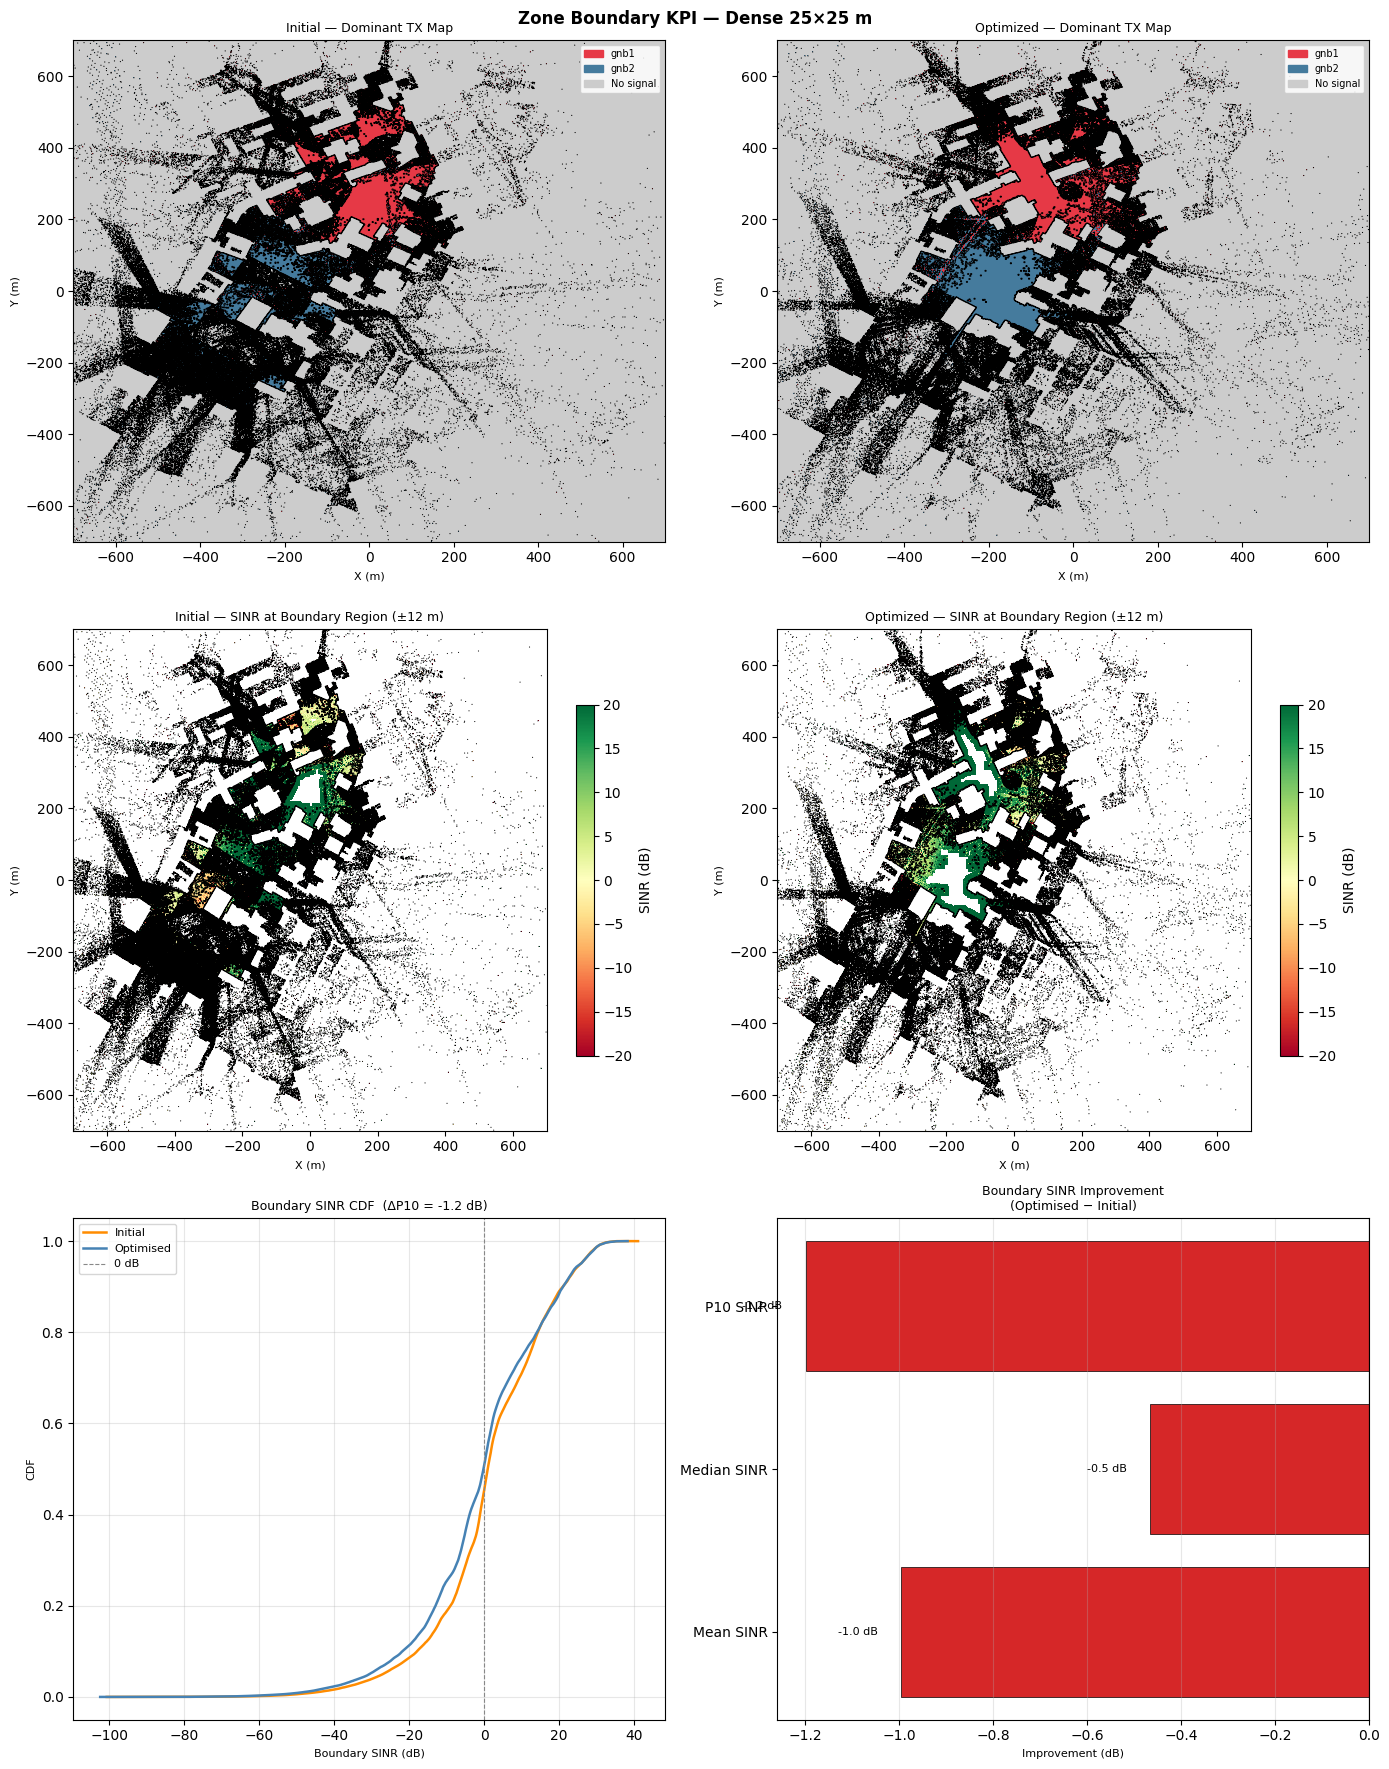

KeyError: 'Triangulated SGD (256 pts)'

In [14]:
# ── BOUNDARY KPI — side-by-side: best dense vs best triangulated ──────────────
from experiment_runner import plot_service_boundaries

_tx_names_2 = [TX1_NAME, TX2_NAME]

for _label in ["Dense 25×25 m", "Triangulated SGD (256 pts)"]:
    _stats, _ = _scale_sinr_stats[_label]
    print(f"\n{'═'*60}")
    print(f"  {_label}")
    print(f"{'═'*60}")
    _bnd_i = _stats["boundary"]["initial"]
    _bnd_o = _stats["boundary"]["optimized"]
    _bnd_d = _stats["boundary"]["improvement"]
    print(f"  Boundary cells  :  {_bnd_i['n_boundary_cells']:,}  →  {_bnd_o['n_boundary_cells']:,}")
    print(f"  Boundary frac   :  {_bnd_i['boundary_fraction']:.3f}  →  {_bnd_o['boundary_fraction']:.3f}")
    print(f"  SINR nbhd mean  :  {_bnd_i['boundary_sinr_mean_db']:+.1f} dB  →  "
          f"{_bnd_o['boundary_sinr_mean_db']:+.1f} dB  ({_bnd_d['boundary_sinr_mean_db']:+.1f} dB)")
    print(f"  SINR nbhd P10   :  {_bnd_i['boundary_sinr_p10_db']:+.1f} dB  →  "
          f"{_bnd_o['boundary_sinr_p10_db']:+.1f} dB  ({_bnd_d['boundary_sinr_p10_db']:+.1f} dB)")
    plot_service_boundaries(
        stats=_stats,
        map_config=MAP_CONFIG,
        tx_names=_tx_names_2,
        title=f"Zone Boundary KPI — {_label}",
    )

In [ ]:
# ── BOUNDARY KPI — cross-method summary ──────────────────────────────────────
# Extracts boundary_sinr_p10_db (optimized) and its improvement for every
# scaling-experiment method, then plots a grouped bar chart for direct comparison.

_bnd_summary_keys = [
    ("Dense 20×20 m",              "#a0c4e8", "-"),
    ("Dense 10×10 m",              "#4e79a7", "-"),
    ("Dense 5×5 m",                "#f28e2b", "-"),
    ("Dense 2.5×2.5 m",            "#76b7b2", "-"),
    ("Triangulated SGD (64 pts)",  "#b8deb0", ":"),
    ("Triangulated SGD (128 pts)", "#7dc475", ":"),
    ("Triangulated SGD (256 pts)", "#59a14f", ":"),
]

_bnd_rows = []
for _label, _color, _ls in _bnd_summary_keys:
    if _label not in _scale_sinr_stats:
        continue
    _stats, _ = _scale_sinr_stats[_label]
    _bnd = _stats["boundary"]
    _bnd_rows.append({
        "label":           _label,
        "color":           _color,
        "linestyle":       _ls,
        "opt_mean":        _bnd["optimized"]["boundary_sinr_mean_db"],
        "opt_p10":         _bnd["optimized"]["boundary_sinr_p10_db"],
        "init_p10":        _bnd["initial"]["boundary_sinr_p10_db"],
        "delta_mean":      _bnd["improvement"]["boundary_sinr_mean_db"],
        "delta_p10":       _bnd["improvement"]["boundary_sinr_p10_db"],
        "boundary_frac":   _bnd["optimized"]["boundary_fraction"],
        "n_boundary":      _bnd["optimized"]["n_boundary_cells"],
    })

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: optimized boundary SINR (mean + P10) ───────────────────────────────
ax0 = axes[0]
_y  = np.arange(len(_bnd_rows))
_w  = 0.38
ax0.barh(_y + _w/2, [r["opt_mean"] for r in _bnd_rows], height=_w,
         color=[r["color"] for r in _bnd_rows], edgecolor="white", linewidth=0.5,
         label="Mean")
ax0.barh(_y - _w/2, [r["opt_p10"]  for r in _bnd_rows], height=_w,
         color=[r["color"] for r in _bnd_rows], edgecolor="black", linewidth=0.5,
         alpha=0.55, label="P10")
ax0.set_yticks(_y)
ax0.set_yticklabels([r["label"] for r in _bnd_rows], fontsize=8)
ax0.axvline(0, color="black", linewidth=0.8)
ax0.set_xlabel("Boundary SINR — Optimized (dB)")
ax0.set_title("Optimized Boundary SINR\n(solid=mean, faded=P10)")
ax0.legend(fontsize=8)
ax0.grid(True, axis="x", alpha=0.3)
ax0.spines[["top", "right"]].set_visible(False)
ax0.invert_yaxis()

# ── Middle: SINR improvement (P10 delta) ─────────────────────────────────────
ax1 = axes[1]
_deltas = [r["delta_p10"] for r in _bnd_rows]
_bar_cols = ["#2CA02C" if d >= 0 else "#D62728" for d in _deltas]
bars = ax1.barh(_y, _deltas, color=_bar_cols, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, _deltas):
    ha = "left" if val >= 0 else "right"
    ax1.text(val + (0.05 if val >= 0 else -0.05),
             bar.get_y() + bar.get_height() / 2,
             f"{val:+.1f}", va="center", ha=ha, fontsize=7.5)
ax1.set_yticks(_y)
ax1.set_yticklabels([r["label"] for r in _bnd_rows], fontsize=8)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_xlabel("ΔBoundary SINR P10 (dB)  [Optimized − Initial]")
ax1.set_title("Boundary SINR P10 Improvement\n(green = better post-opt)")
ax1.grid(True, axis="x", alpha=0.3)
ax1.spines[["top", "right"]].set_visible(False)
ax1.invert_yaxis()

# ── Right: CDFs of boundary SINR across methods (optimized only) ──────────────
ax2 = axes[2]
for r in _bnd_rows:
    _label  = r["label"]
    _stats, _ = _scale_sinr_stats[_label]
    _raw = np.asarray(_stats["boundary"]["optimized"]["_boundary_sinr_values"])
    _finite = _raw[np.isfinite(_raw)]
    if _finite.size == 0:
        continue
    xs  = np.sort(_finite)
    cdf = np.arange(1, len(xs) + 1) / len(xs)
    ax2.plot(xs, cdf, color=r["color"], linestyle=r["linestyle"],
             linewidth=1.5, label=_label)
ax2.axvline(0, color="#888888", linewidth=0.8, linestyle="--")
ax2.set_xlabel("Boundary SINR (dB)")
ax2.set_ylabel("CDF")
ax2.set_title("Boundary SINR CDF — All Methods\n(optimized configs)")
ax2.legend(fontsize=7, loc="lower right")
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle(
    "Zone Boundary KPI — Dense PathSolver vs. Triangulated SGD  (Duke Scene)",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig("boundary_kpi_scaling_duke.pdf", bbox_inches="tight")
plt.show()

# ── Numeric summary table ─────────────────────────────────────────────────────
print(f"\n{'Method':<32}  {'Init P10':>9}  {'Opt P10':>8}  {'ΔP10':>7}  {'Opt Mean':>9}  {'Bnd frac':>9}")
print("─" * 82)
for r in _bnd_rows:
    print(f"  {r['label']:<30}  {r['init_p10']:>9.1f}  {r['opt_p10']:>8.1f}  "
          f"{r['delta_p10']:>+7.1f}  {r['opt_mean']:>9.1f}  {r['boundary_frac']:>9.3f}")